In [ ]:
# 📦 Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("data/raw/raw.csv")

df.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
print("📊 Estatísticas Descritivas:")
df.describe().round(2)

📊 Estatísticas Descritivas:


,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


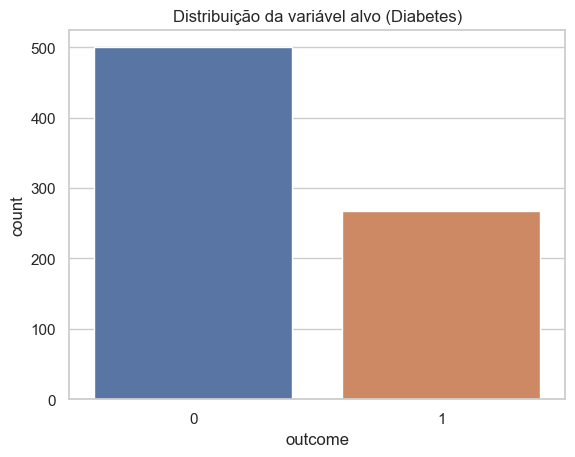

outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [8]:
sns.countplot(x="outcome", data=df)
plt.title("Distribuição da variável alvo (Diabetes)")
plt.show()

df["outcome"].value_counts(normalize=True)

In [9]:
cols = ['glucose','bloodpressure','skinthickness','insulin','bmi']

for col in cols:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

glucose: 5 zeros
bloodpressure: 35 zeros
skinthickness: 227 zeros
insulin: 374 zeros
bmi: 11 zeros


### Histograma

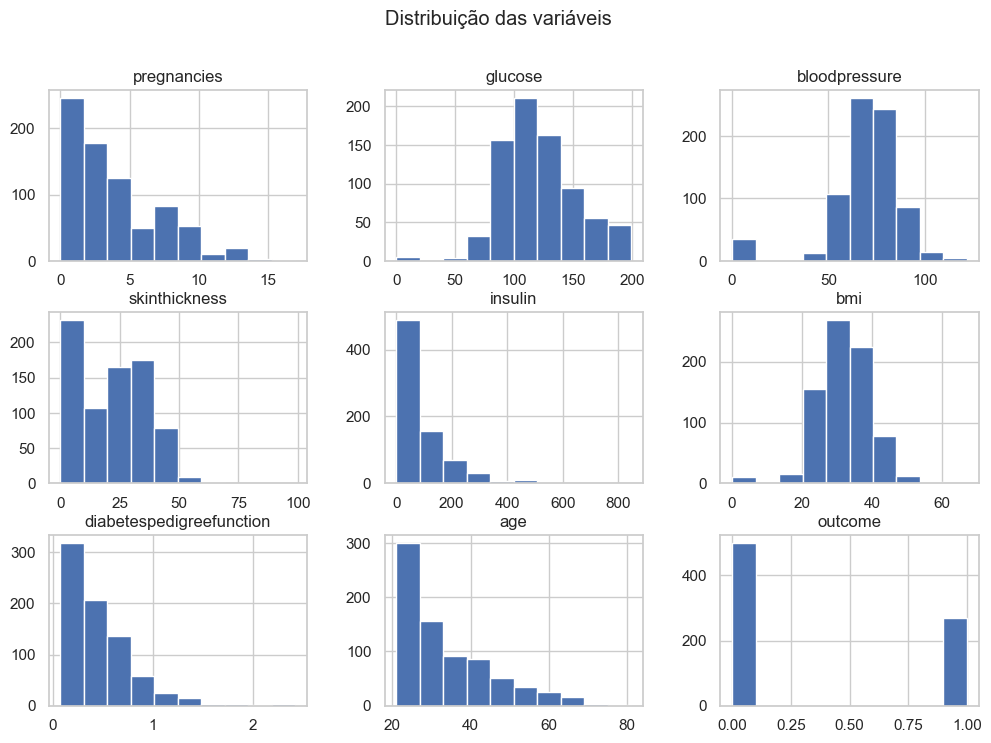

In [10]:
df.hist(figsize=(12,8))
plt.suptitle("Distribuição das variáveis")
plt.show()

### Outliers

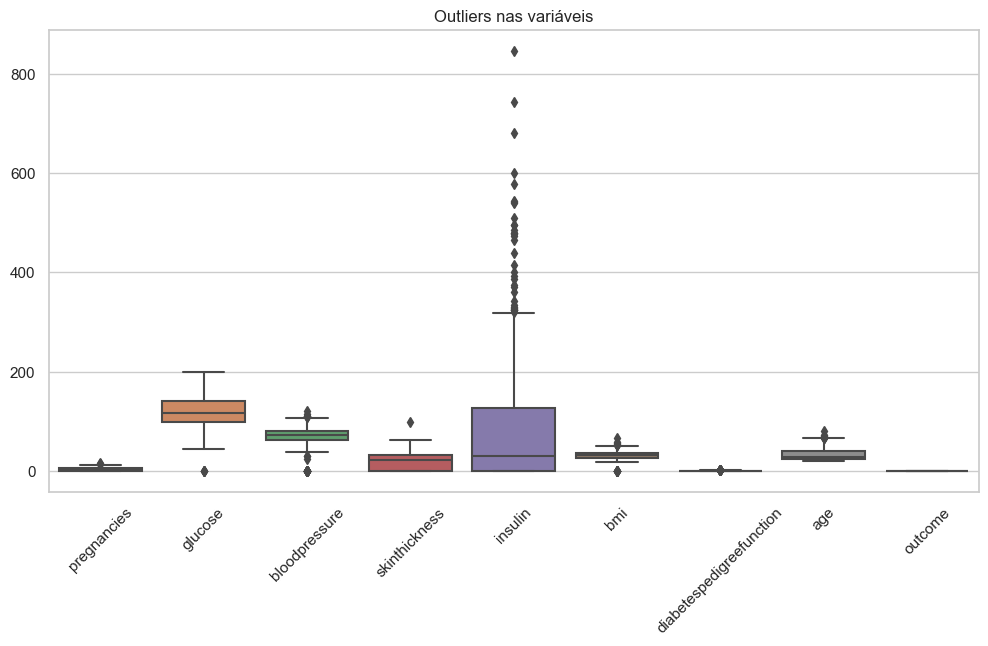

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outliers nas variáveis")
plt.show()

### Correlação

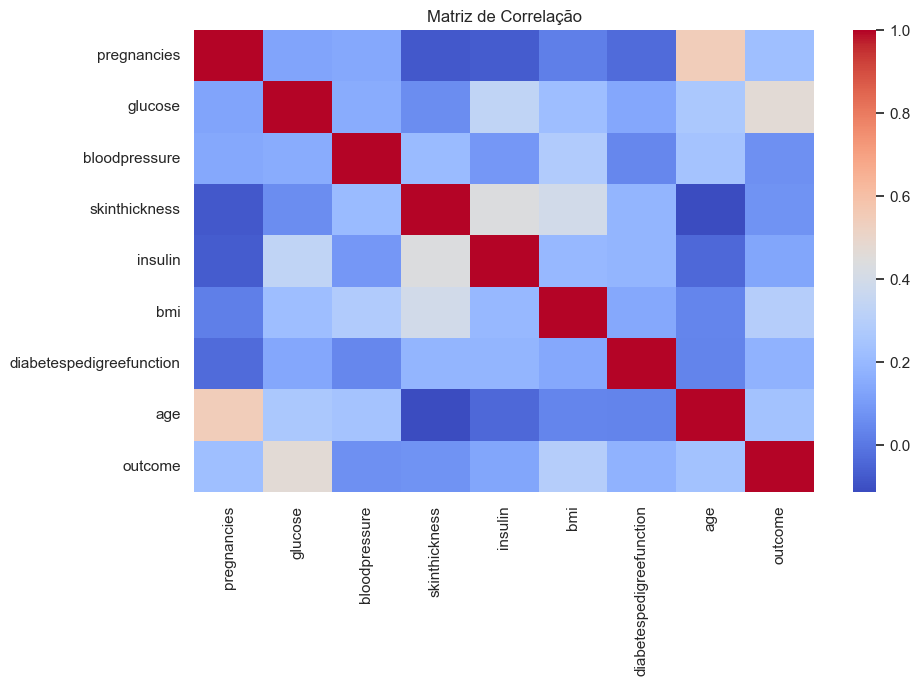

In [18]:
df_numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

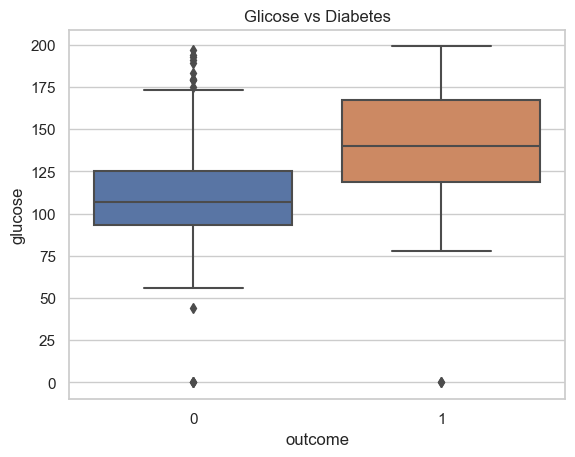

In [19]:
#Glucose vs Outcome

sns.boxplot(x="outcome", y="glucose", data=df)
plt.title("Glicose vs Diabetes")
plt.show()

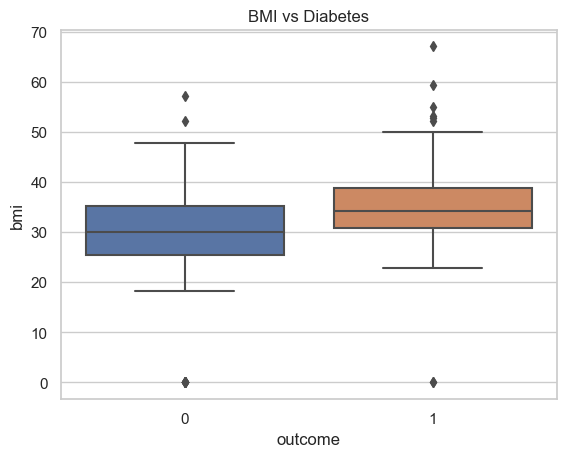

In [20]:
#BMI vs Outcome

sns.boxplot(x="outcome", y="bmi", data=df)
plt.title("BMI vs Diabetes")
plt.show()

### Scatter Plot

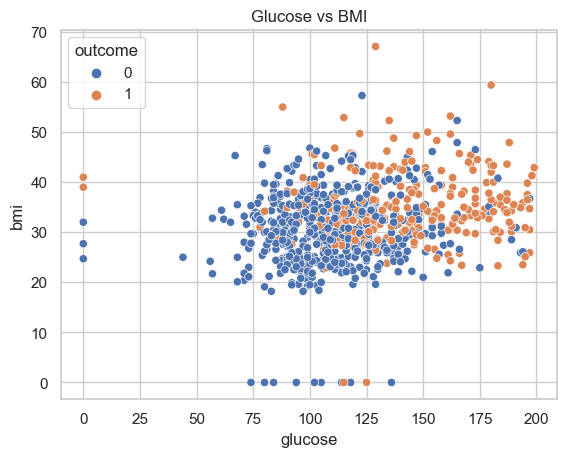

In [21]:
sns.scatterplot(x="glucose", y="bmi", hue="outcome", data=df)
plt.title("Glucose vs BMI")
plt.show()

### Pair Plot

C:\Users\julia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\julia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\julia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\julia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is 

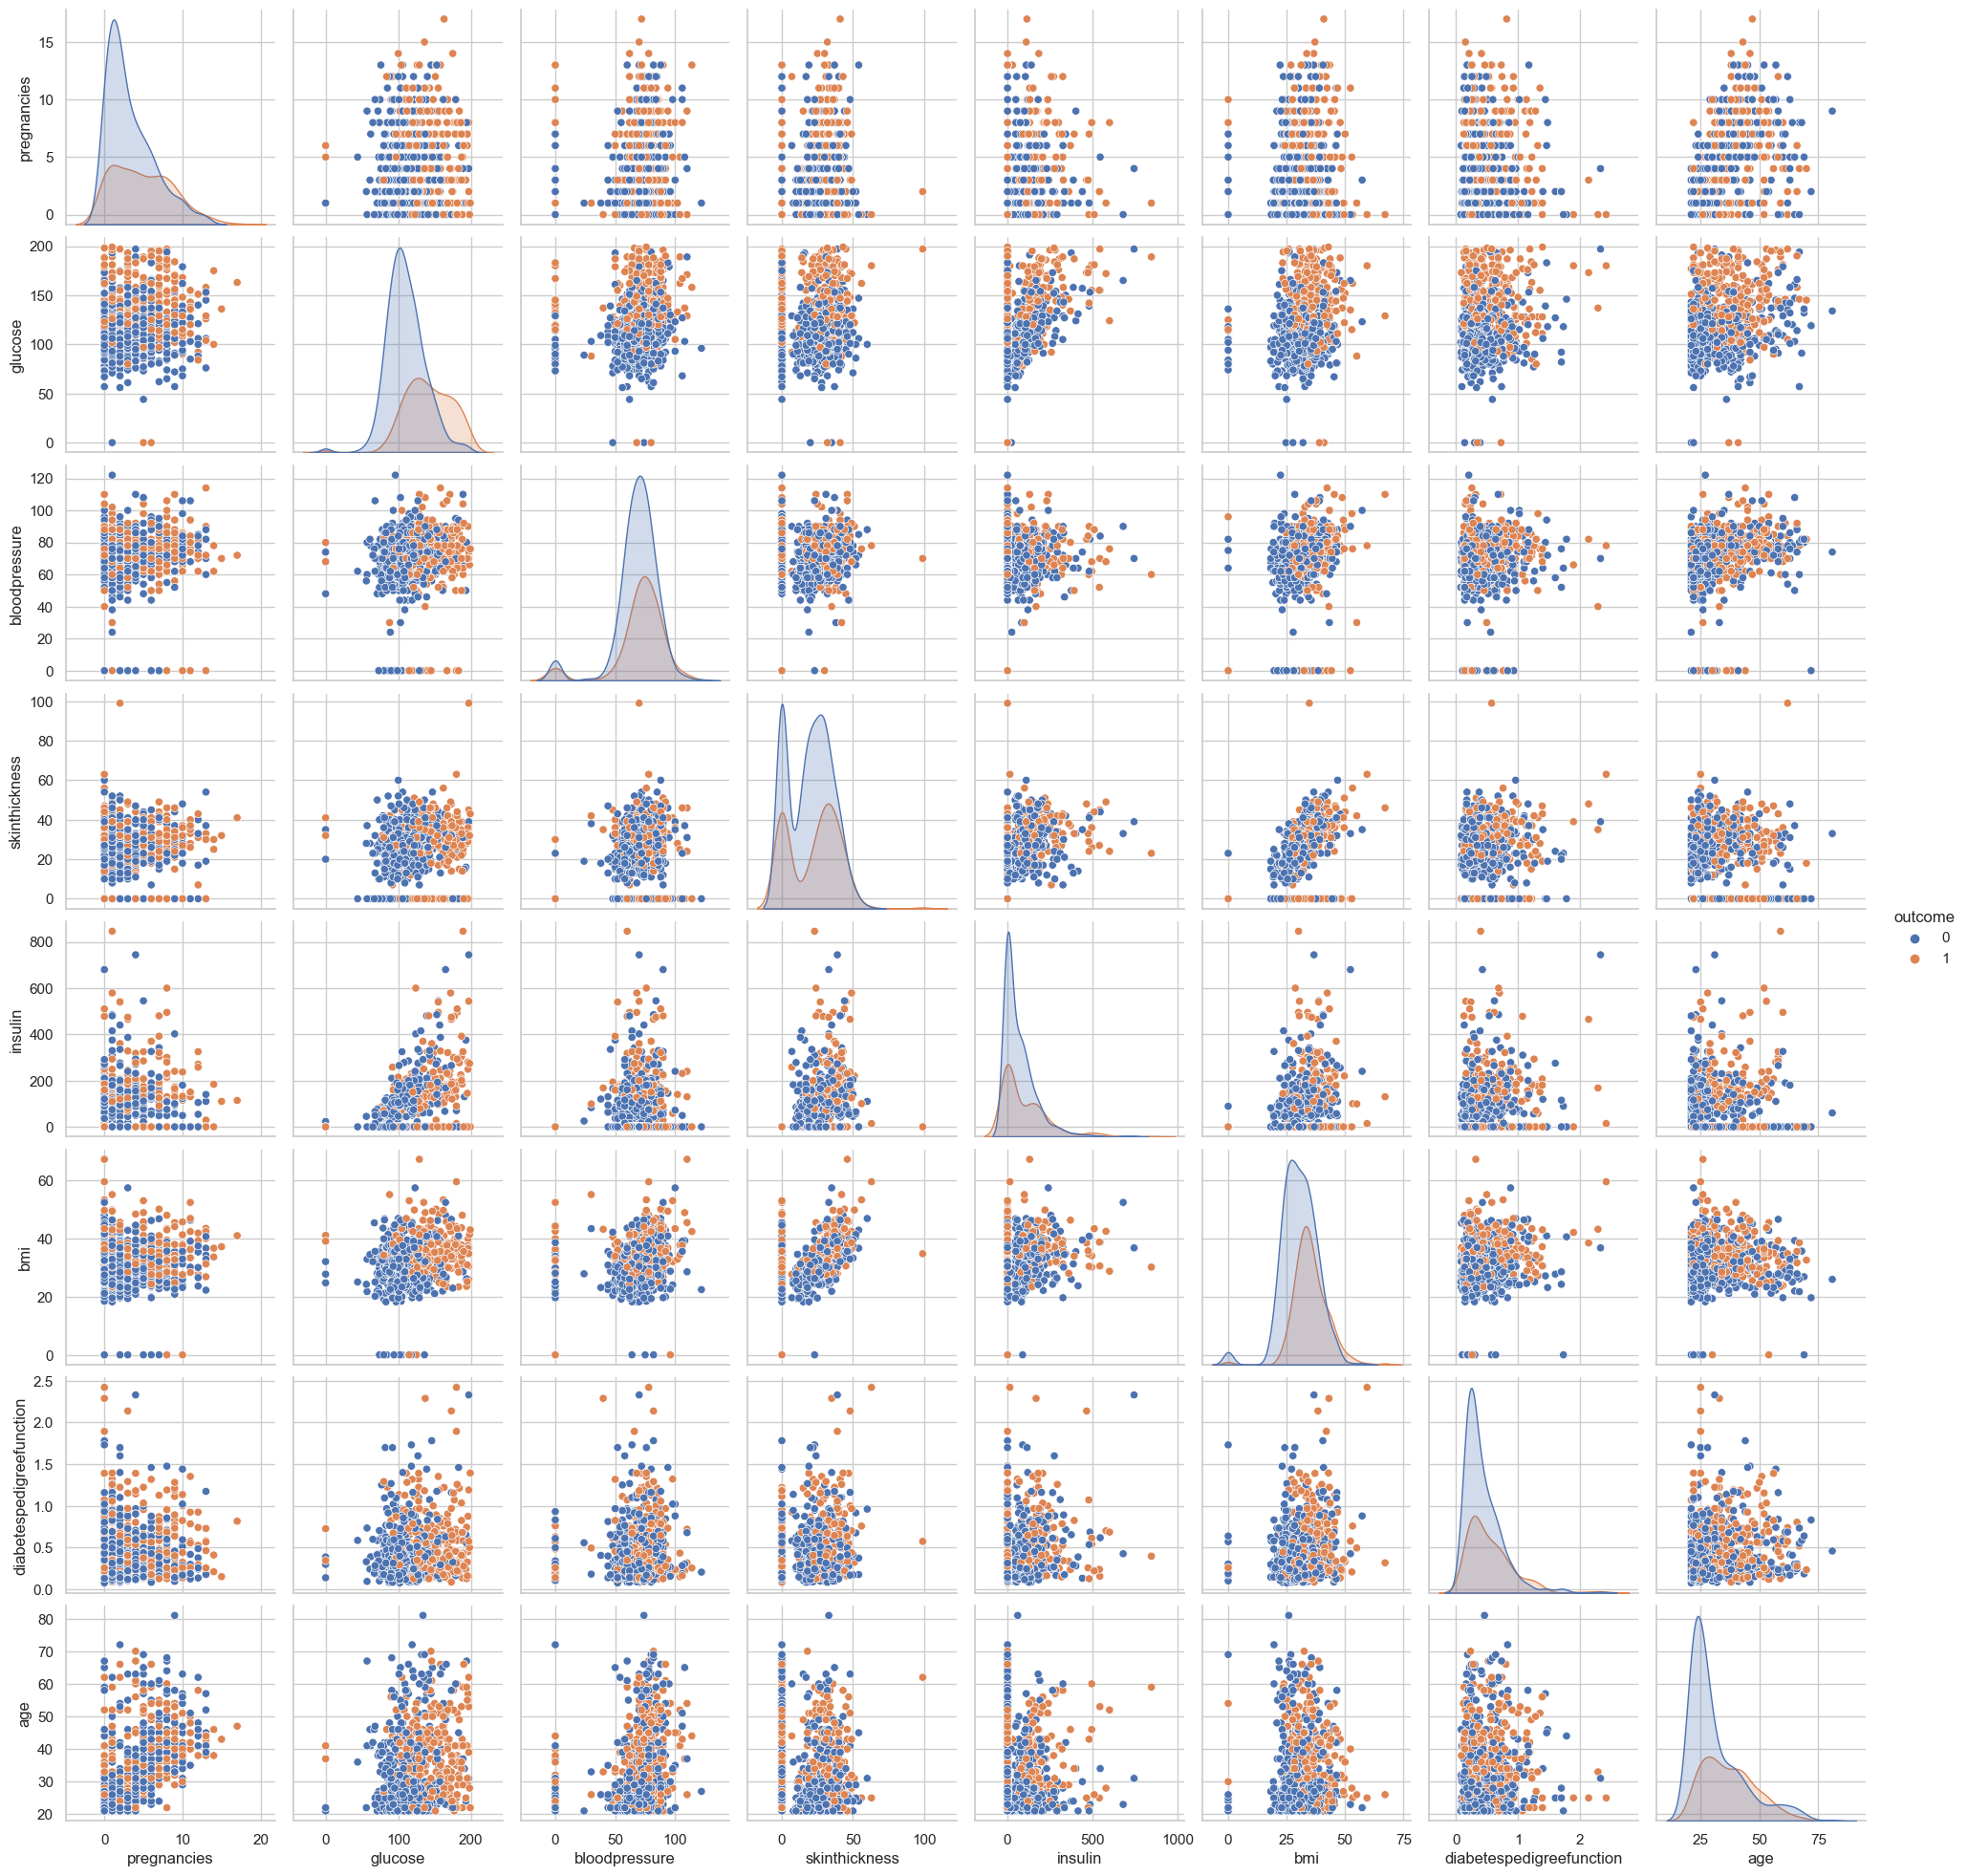

In [22]:
sns.pairplot(df, hue="outcome")
plt.show()